# Importação das Bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Download do Dataset

In [5]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("yasserh/titanic-dataset")

df = pd.read_csv(f"{path}/Titanic-Dataset.csv")

Using Colab cache for faster access to the 'titanic-dataset' dataset.


# Visualização dos Dados

In [6]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Pré-processamento


   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0


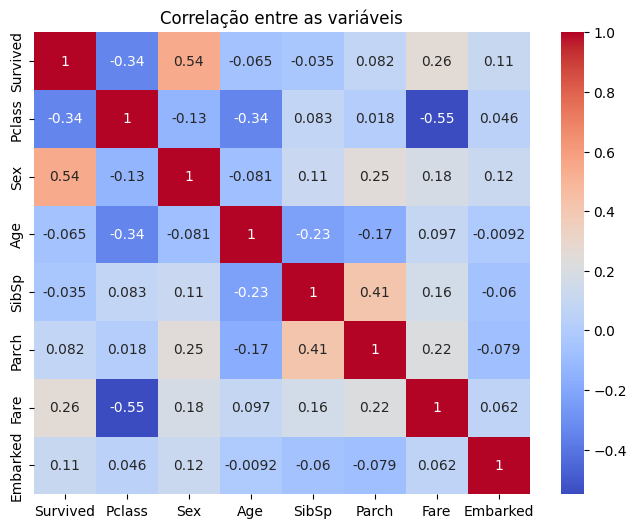

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Conversão de variáveis categóricas
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Remoção de colunas que não serão utilizadas
df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

print(df.head())

# Mapa de correlação
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre as variáveis")
plt.show()

# Separação dos dados

In [8]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (712, 7)
Teste : (179, 7)


# Modelo da Árvore de Decisão

Acurácia: 0.7989

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



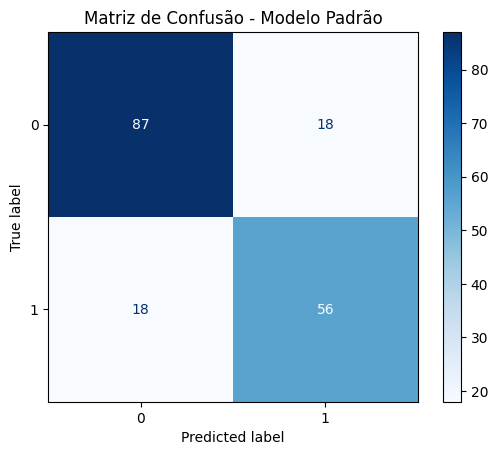

In [9]:
modelo_padrao = DecisionTreeClassifier(random_state=42)

modelo_padrao.fit(X_train, y_train)

pred_padrao = modelo_padrao.predict(X_test)

acc_padrao = accuracy_score(y_test, pred_padrao)

print(f"Acurácia: {acc_padrao:.4f}\n")

print("Relatório de Classificação")
print(classification_report(y_test, pred_padrao))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_padrao,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Modelo Padrão")
plt.show()

# Otimização com GridSearchCV

In [10]:
param_grid = {
    "max_depth": [3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)

print(f"\nMelhor score de validação: {grid.best_score_:.4f}")

Melhores hiperparâmetros encontrados:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}

Melhor score de validação: 0.8230


# Avaliação do Modelo Otimizado

Acurácia do modelo otimizado: 0.7989

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



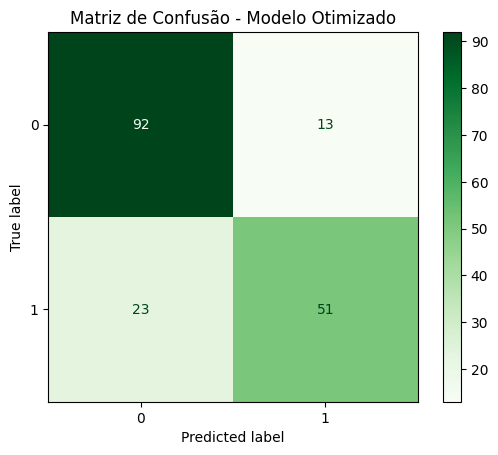

In [11]:
modelo_otimizado = grid.best_estimator_

pred_grid = modelo_otimizado.predict(X_test)

acc_grid = accuracy_score(y_test, pred_grid)

print(f"Acurácia do modelo otimizado: {acc_grid:.4f}\n")

print(classification_report(y_test, pred_grid))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_grid,
    cmap="Greens"
)

plt.title("Matriz de Confusão - Modelo Otimizado")
plt.show()

# Comparação dos Modelos

,Modelo,Acurácia
0,Árvore Padrão,0.798883
1,Árvore Otimizada,0.798883


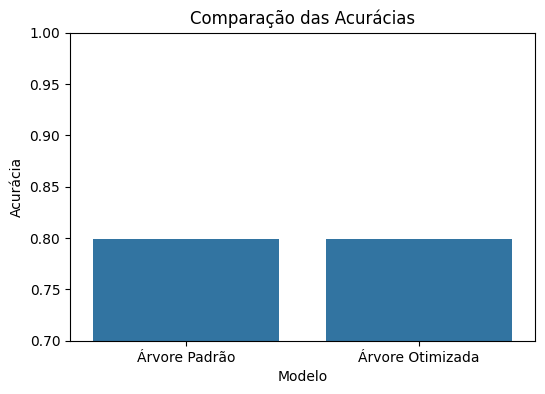

In [12]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Árvore Padrão",
        "Árvore Otimizada"
    ],
    "Acurácia": [
        acc_padrao,
        acc_grid
    ]
})

display(comparacao)

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparacao,
    x="Modelo",
    y="Acurácia"
)

plt.ylim(0.70,1.00)
plt.title("Comparação das Acurácias")
plt.show()

# Experimentos Propostos

- Alterar o número de folds da validação cruzada;
- Testar outro modelo (Regressão Logística);
- Utilizar uma quantidade maior de hiperparâmetros;
- Comparar os resultados obtidos

In [13]:
print("========== Testando diferentes valores de CV ==========\n")

for cv in [3, 10]:

    grid_cv = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_cv.fit(X_train, y_train)

    print(f"CV = {cv}")
    print(f"Melhor Score: {grid_cv.best_score_:.4f}")
    print(f"Melhores Parâmetros: {grid_cv.best_params_}")
    print("-"*50)

========== Testando diferentes valores de CV ==========

CV = 3
Melhor Score: 0.8217
Melhores Parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
--------------------------------------------------
CV = 10
Melhor Score: 0.8245
Melhores Parâmetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
--------------------------------------------------


# Regressão Logística

In [14]:
modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train, y_train)

pred_log = modelo_log.predict(X_test)

acc_log = accuracy_score(y_test, pred_log)

print(f"Acurácia da Regressão Logística: {acc_log:.4f}")

print(classification_report(y_test, pred_log))

Acurácia da Regressão Logística: 0.7989
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [15]:
param_log = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_log,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_log.best_params_)

pred_log_grid = grid_log.best_estimator_.predict(X_test)

acc_log_grid = accuracy_score(y_test, pred_log_grid)

print(f"Acurácia otimizada: {acc_log_grid:.4f}")

Melhores parâmetros:
{'C': 0.1, 'solver': 'liblinear'}
Acurácia otimizada: 0.7989


# Conclusões

### 1. Quais foram os melhores hiperparâmetros encontrados para cada modelo?

**Árvore de Decisão**

Os melhores hiperparâmetros encontrados pelo **GridSearchCV** foram:

- `criterion = "entropy"`
- `max_depth = 3`
- `min_samples_split = 2`

O melhor score obtido na validação cruzada (CV = 5) foi de **0.8230**.

**Regressão Logística**

Os melhores hiperparâmetros encontrados pelo **GridSearchCV** foram:

- `C = 0.1`
- `solver = "liblinear"`

### 2. O modelo otimizado teve uma acurácia melhor que o modelo padrão? Quanto?

Neste experimento, **não houve melhora na acurácia** para nenhum dos modelos.

**Árvore de Decisão**

- Modelo padrão: **0.7989**
- Modelo otimizado: **0.7989**
- Diferença: **0.0000**

Portanto, a otimização não trouxe ganho de desempenho no conjunto de teste.

**Regressão Logística**

- Modelo padrão: **0.7989**
- Modelo otimizado: **0.7989**
- Diferença: **0.0000**

Da mesma forma, o GridSearchCV não proporcionou melhoria na acurácia desse modelo.

### 3. O que aconteceu quando você mudou o número de folds na Validação Cruzada (CV)?

Ao alterar o número de folds, foi possível observar pequenas variações no score de validação cruzada, enquanto os melhores hiperparâmetros permaneceram os mesmos.

- **CV = 3:** Score = **0.8217**
- **CV = 5:** Score = **0.8230**
- **CV = 10:** Score = **0.8245**

O melhor resultado foi obtido utilizando **10 folds**. Em geral, aumentar o número de folds fornece uma estimativa mais confiável do desempenho do modelo, porém aumenta o tempo de processamento, pois o treinamento é repetido mais vezes.


### 4. Você acha que o GridSearch compensa o tempo de processamento? Por quê?

Neste experimento, o **GridSearchCV** não aumentou a acurácia no conjunto de teste para nenhum dos modelos. Mesmo assim, considero que ele é uma ferramenta importante, pois automatiza a busca pelos melhores hiperparâmetros, evitando ajustes manuais e permitindo explorar diferentes combinações de forma sistemática.

Embora não tenha ocorrido melhoria neste conjunto de dados, o score de validação cruzada da Árvore de Decisão aumentou levemente com um número maior de folds, indicando que o método pode encontrar configurações mais robustas em outras situações.

Em problemas mais complexos ou com um espaço maior de hiperparâmetros, o GridSearchCV costuma compensar o tempo de processamento, pois pode gerar modelos com desempenho significativamente superior ao obtido utilizando apenas os parâmetros padrão.